### Dylan Navarro Badilla

In [1]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Jun 19 20:41:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import tensorflow as tf
print(tf.test.gpu_device_name())
print(tf.__version__)

/device:GPU:0
2.20.0


In [4]:
# importación de librerías
import time #tiempo de sistema
import numpy as np  #biblioteca para realizar operaciones con vectores y matrices
import matplotlib.pyplot as plt #biblioteca para visualización de datos
import tensorflow as tf

## Práctica 4

Haciendo uso del dataset de modas MNIST empleando `tf.keras.datasets`, el cual maneja las siguientes etiquetas:

In [5]:
# 10 classes
LABEL_NAMES = ['t_shirt',
               'trouser',
               'pullover',
               'dress',
               'coat',
               'sandal',
               'shirt',
               'sneaker',
               'bag',
               'ankle_boots']

Desarolle los siguientes enunciandos:

1.  Implemente una celda de código que genere como salida los arreglos de entrenamiento y validación del set de datos de prendas de vestir MNIST. Debe transformar el arreglo de datos para añadir el canal de color.
2.  Construya un modelo de CNNs utilizando el método facilitado en el cuaderno, luego compílelo con `tf.keras.optimizers` y los siguientes argumentos:
  *   Optimizador: Adam.
  *   Tasa de aprendizaje: 0.001.
  *   Función de pérdidas: `sparse_categorical_crossentropy`.
  *   Métrica: `accuracy`.
3.  Entrene el modelo de red neuronal y ejecute su validación usando los datos generados en el primer inciso con los siguientes parámetros:
  *   Resolución de datos: 32-bits en punto flotante (entrenamiento y validación).
  *   Cantidad de épocas: 17
  *   Cantidad de pasos por época: 60
4. Genere los gráficos relacionados con la función de error y la exactitud tanto en el entrenamiento como en la validación (`validation_split=0.20`).
5. Proceda a almacenar en su sesión de Colab los pesos resultantes del entrenamiento en formato `.h5` y ejecute el proceso de evaluación del modelo de red neuronal.
6. **Opcional:** Genere una visualización de las predicciones de prendas de vestir empleado el modelo evaluado.


### 1)  Implemente una celda de código que genere como salida los arreglos de entrenamiento y validación del set de datos de prendas de vestir MNIST. Debe transformar el arreglo de datos para añadir el canal de color.

##### Según la página de kaggle https://www.kaggle.com/datasets/zalando-research/fashionmnist , el set de datos se llama fashion_mnist, contiene 60000 ejemplares y 10 clases. Por lo que se carga el set de datos y se comprueban los tamaños:

In [6]:
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.fashion_mnist.load_data()
print('MNIST shape: ', x_train.shape, x_val.shape)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_val = x_val.reshape((x_val.shape[0], 28, 28, 1))
input_shape = x_train.shape[1:]
print('input shape:', input_shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST shape:  (60000, 28, 28) (10000, 28, 28)
input shape: (28, 28, 1)


### 2)  Construya un modelo de CNNs utilizando el método facilitado en el cuaderno, luego compílelo con `tf.keras.optimizers` y los siguientes argumentos:
  *   Optimizador: Adam.
  *   Tasa de aprendizaje: 0.001.
  *   Función de pérdidas: `sparse_categorical_crossentropy`.
  *   Métrica: `accuracy`.

In [7]:
def create_model(train_shape):
  # Modelo secuencial
  model = tf.keras.models.Sequential()
  # Capa de normalización de lote: normaliza la salida usando la media y la desviación estándar del lote actual de entradas
  model.add(tf.keras.layers.BatchNormalization(input_shape=train_shape))
  # 1era capa convolucional en 2D
  model.add(tf.keras.layers.Conv2D(64, (5, 5), padding='same', activation='relu'))
  model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  # 2da capa convolucional en 2D
  model.add(tf.keras.layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
  model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  # 3era capa convolucional en 2D
  model.add(tf.keras.layers.Conv2D(256, (5, 5), padding='same', activation='relu'))
  model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  # 4ta capa convolucional en 2D
  model.add(tf.keras.layers.Conv2D(512, (5, 5), padding='same', activation='relu'))
  model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  # Aplaneamiento de los datos
  model.add(tf.keras.layers.Flatten())
  # 5ta capa oculta
  model.add(tf.keras.layers.Dense(128, activation='relu'))
  # Dropout: generalización
  model.add(tf.keras.layers.Dropout(0.2))
  # Capa completamente conectada de clasificación
  model.add(tf.keras.layers.Dense(10, activation='softmax'))
  return model

##### Para compilar (importante, agregar el argumento de la función create_model):

In [8]:
with tf.device('/gpu:0'):
  model = create_model(input_shape)
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  t = time.time()
  model.fit(x_train, y_train, epochs=15)
  gpu_time = time.time() - t
  model.evaluate(x_val, y_val)

print ("GPU time: ", gpu_time, "s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.8401 - loss: 0.4406
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8979 - loss: 0.2803
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9132 - loss: 0.2384
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9231 - loss: 0.2091
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9319 - loss: 0.1809
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9391 - loss: 0.1611
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9471 - loss: 0.1428
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9518 - loss: 0.1274
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9565 - loss: 0.1141
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9621 - loss: 0.0991
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9666 - loss: 0.0889
Epoch 12/15
1875/18

### 3)  Entrene el modelo de red neuronal y ejecute su validación usando los datos generados en el primer inciso con los siguientes parámetros:
  *   Resolución de datos: 32-bits en punto flotante (entrenamiento y validación).
  *   Cantidad de épocas: 17
  *   Cantidad de pasos por época: 60

In [9]:
with tf.device('/gpu:0'):
  t = time.time()
  model.fit(x_train.astype(np.float32),
            y_train.astype(np.float32),
            epochs=17,
            steps_per_epoch=60,
            validation_data=(x_val.astype(np.float32), y_val.astype(np.float32)))
  gpu_time = time.time() - t
print ("GPU time: ", gpu_time, "s")

Epoch 1/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 200ms/step - accuracy: 0.9870 - loss: 0.0357 - val_accuracy: 0.9216 - val_loss: 0.4072
Epoch 2/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9929 - loss: 0.0195 - val_accuracy: 0.9218 - val_loss: 0.4605
Epoch 3/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9221 - val_loss: 0.5035
Epoch 4/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9960 - loss: 0.0111 - val_accuracy: 0.9214 - val_loss: 0.5386
Epoch 5/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9213 - val_loss: 0.5814
Epoch 6/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9212 - val_loss: 0.6192
Epoch 7/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9983 - loss: 0.0053 - val_accuracy: 0.9220 - val_loss: 0.6602
Epoch 8/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9989 - loss: 0.0040 - val_accu

### 4) Genere los gráficos relacionados con la función de error y la exactitud tanto en el entrenamiento como en la validación (`validation_split=0.20`).

##### Se vuelve a entrenar el modelo, pero ahora utilizando un histórico de la red neuronal:

In [15]:
model = None
model = create_model(train_shape=x_train.shape[1:])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

with tf.device('/gpu:0'):
    t = time.time()
    history = model.fit(
        x_train.astype(np.float32),
        y_train.astype(np.float32),
        epochs=17,
        steps_per_epoch=60,
        validation_split=0.20
    )
    gpu_time = time.time() - t

print("GPU time: ", gpu_time, "s")

Epoch 1/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.6921 - loss: 0.8255 - val_accuracy: 0.8238 - val_loss: 0.4683
Epoch 2/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8513 - loss: 0.4054 - val_accuracy: 0.8674 - val_loss: 0.3592
Epoch 3/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.8843 - loss: 0.3177 - val_accuracy: 0.8846 - val_loss: 0.3115
Epoch 4/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9024 - loss: 0.2698 - val_accuracy: 0.9076 - val_loss: 0.2640
Epoch 5/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.9123 - loss: 0.2423 - val_accuracy: 0.9082 - val_loss: 0.2494
Epoch 6/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9222 - loss: 0.2111 - val_accuracy: 0.9149 - val_loss: 0.2357
Epoch 7/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9298 - loss: 0.1934 - val_accuracy: 0.9177 - val_loss: 0.2270
Epoch 8/17
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9391 - loss: 0.1661 - val_accuracy:

##### Gráficos:

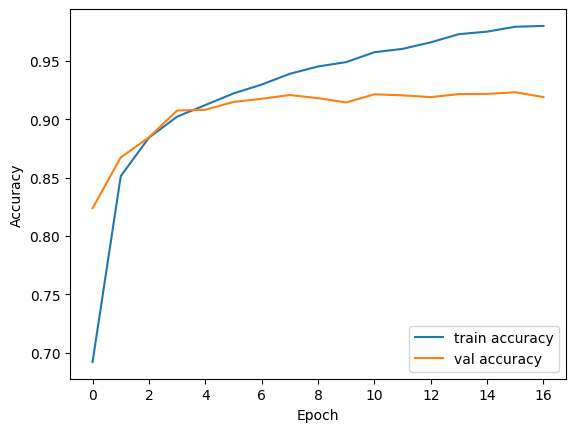

In [16]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

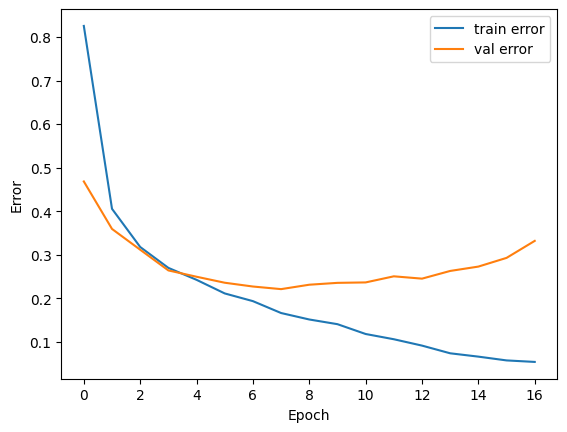

In [17]:
plt.plot(history.history['loss'], label='train error')
plt.plot(history.history['val_loss'], label='val error')
plt.ylabel('Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

### 5) Proceda a almacenar en su sesión de Colab los pesos resultantes del entrenamiento en formato `.h5` y ejecute el proceso de evaluación del modelo de red neuronal.

##### Se guardan los pesos:

In [19]:
model.save_weights('./fashion_mnist.weights.h5', overwrite=True)

##### Evaluación:

In [20]:
loaded_model = create_model(input_shape)
loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
loaded_model.load_weights('./fashion_mnist.weights.h5')
loaded_model.evaluate(x_train.astype(np.float32), y_train.astype(np.float32))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9714 - loss: 0.0992


[0.09916619211435318, 0.9714000225067139]